# 04 - Dataset Balancing & Augmentation for YOLOv8 Retail Theft Detection

**Purpose:** Address class imbalance through targeted augmentation

**Objectives:**
- Analyze class imbalance quantitatively
- Apply focused augmentation to minority classes (Theft, Shopping-Cart)
- Control dominance of Normal class
- Apply realistic retail-surveillance augmentations
- Generate augmentation preview samples

**Augmentation Techniques:**
- Horizontal flip
- Random brightness and contrast
- Light motion blur
- Gaussian noise
- Random scaling and cropping
- Color jitter

---

## 1. Setup and Imports

In [1]:
# Install required packages
!pip install opencv-python pillow numpy pandas albumentations tqdm pyyaml matplotlib --quiet

In [2]:
!pip install opencv-python opencv-python-headless opencv-contrib-python --quiet

ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\shaho\\anaconda3\\envs\\notebook\\Lib\\site-packages\\cv2\\cv2.pyd'
Consider using the `--user` option or check the permissions.



In [3]:
!pip install albumentations --upgrade


In [4]:
import os
import sys
import cv2
import yaml
import json
import shutil
import random
from pathlib import Path
from datetime import datetime
from collections import defaultdict
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.core.transforms_interface import ImageOnlyTransform

print("All imports successful!")
print(f"Albumentations version: {A.__version__}")

All imports successful!
Albumentations version: 2.0.8


In [5]:
# Configuration
BASE_DIR = Path(r"c:/Users/shaho/OneDrive - Nile University/Desktop/AletrixGrad")

# Use cleaned dataset if available
CLEANED_DIR = BASE_DIR / "dataset_cleaned"
ORIGINAL_DIR = BASE_DIR / "cc-tv-footage-annotation-b8-lcysc-b1-2"

if CLEANED_DIR.exists() and (CLEANED_DIR / "train" / "images").exists():
    SOURCE_DIR = CLEANED_DIR
    print(f"Using cleaned dataset: {SOURCE_DIR}")
else:
    SOURCE_DIR = ORIGINAL_DIR
    print(f"Using original dataset: {SOURCE_DIR}")

AUGMENTED_DIR = BASE_DIR / "dataset_augmented"
OUTPUT_DIR = BASE_DIR / "outputs"
VIS_DIR = BASE_DIR / "visualizations"

# Create directories
AUGMENTED_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)
VIS_DIR.mkdir(exist_ok=True)

# Class definitions
CLASS_NAMES = {
    0: 'Customer-Bagpack',
    1: 'Product',
    2: 'Product-Picked',
    3: 'Shopping-Cart',
    4: 'normal',
    5: 'theft'
}
NUM_CLASSES = 6
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp'}

# Define minority classes for targeted augmentation
MINORITY_CLASSES = {3, 5}  # Shopping-Cart, theft
CRITICAL_CLASS = 5  # theft - highest priority

print(f"\nMinority Classes: {[CLASS_NAMES[c] for c in MINORITY_CLASSES]}")
print(f"Critical Class: {CLASS_NAMES[CRITICAL_CLASS]}")

Using cleaned dataset: c:\Users\shaho\OneDrive - Nile University\Desktop\AletrixGrad\dataset_cleaned

Minority Classes: ['Shopping-Cart', 'theft']
Critical Class: theft


## 2. Analyze Current Class Distribution

In [6]:
def count_class_distribution(dataset_path: Path) -> Dict:
    """Count class distribution in the dataset."""
    class_counts = defaultdict(int)
    images_per_class = defaultdict(list)
    
    for split in ['train', 'valid', 'test']:
        labels_path = dataset_path / split / "labels"
        images_path = dataset_path / split / "images"
        
        if not labels_path.exists():
            continue
        
        for label_file in labels_path.glob("*.txt"):
            try:
                with open(label_file, 'r') as f:
                    lines = f.readlines()
                
                image_classes = set()
                for line in lines:
                    parts = line.strip().split()
                    if len(parts) >= 1:
                        try:
                            class_id = int(parts[0])
                            class_counts[class_id] += 1
                            image_classes.add(class_id)
                        except ValueError:
                            pass
                
                # Track which images contain each class
                for class_id in image_classes:
                    images_per_class[class_id].append({
                        'split': split,
                        'label_file': label_file,
                        'image_stem': label_file.stem
                    })
            except Exception as e:
                print(f"Error reading {label_file}: {e}")
    
    return dict(class_counts), dict(images_per_class)

In [7]:
# Analyze current distribution
print("Analyzing class distribution...")
class_counts, images_per_class = count_class_distribution(SOURCE_DIR)

print("\n" + "="*70)
print("CURRENT CLASS DISTRIBUTION")
print("="*70)

total_annotations = sum(class_counts.values())
for class_id in sorted(class_counts.keys()):
    count = class_counts[class_id]
    num_images = len(images_per_class.get(class_id, []))
    pct = count / total_annotations * 100 if total_annotations > 0 else 0
    print(f"  {class_id}: {CLASS_NAMES[class_id]:20s} {count:6,} annotations ({pct:5.1f}%) in {num_images:,} images")

Analyzing class distribution...

CURRENT CLASS DISTRIBUTION
  0: Customer-Bagpack        605 annotations (  8.2%) in 522 images
  1: Product                 793 annotations ( 10.8%) in 755 images
  2: Product-Picked          778 annotations ( 10.6%) in 738 images
  3: Shopping-Cart           137 annotations (  1.9%) in 136 images
  4: normal                4,626 annotations ( 63.1%) in 1,745 images
  5: theft                   396 annotations (  5.4%) in 323 images


In [8]:
# Calculate target counts for balancing
print("\n" + "="*70)
print("BALANCING STRATEGY")
print("="*70)

# Target: bring minority classes up to ~50-70% of the median class count
counts_list = list(class_counts.values())
median_count = np.median(counts_list)
target_min = int(median_count * 0.5)  # At least 50% of median

augmentation_targets = {}
for class_id in sorted(class_counts.keys()):
    current = class_counts[class_id]
    
    if class_id in MINORITY_CLASSES:
        # Augment minority classes more aggressively
        if class_id == CRITICAL_CLASS:  # theft
            target = int(median_count * 0.8)  # 80% of median for theft
            multiplier = 3  # More augmentation copies
        else:  # Shopping-Cart
            target = int(median_count * 0.6)  # 60% of median
            multiplier = 2
        
        needed = max(0, target - current)
        augmentation_targets[class_id] = {
            'current': current,
            'target': target,
            'needed': needed,
            'multiplier': multiplier
        }
        print(f"\n{CLASS_NAMES[class_id]}:")
        print(f"  Current:    {current:,}")
        print(f"  Target:     {target:,}")
        print(f"  To augment: {needed:,} (multiplier: {multiplier}x)")

print(f"\nMedian class count: {median_count:,.0f}")


BALANCING STRATEGY

Shopping-Cart:
  Current:    137
  Target:     414
  To augment: 277 (multiplier: 2x)

theft:
  Current:    396
  Target:     553
  To augment: 157 (multiplier: 3x)

Median class count: 692


## 3. Define Augmentation Pipelines

In [9]:
import cv2
import albumentations as A

def get_augmentation_pipeline(intensity: str = "medium"):
    """Create augmentation pipeline suitable for retail surveillance."""
    
    if intensity == "light":
        transform = A.Compose(
            [
                A.HorizontalFlip(p=0.5),
                A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.5),
                A.GaussNoise(p=0.3),  # no var_limit here
            ],
            bbox_params=A.BboxParams(format="yolo", label_fields=["class_labels"]),
        )

    elif intensity == "medium":
        transform = A.Compose(
            [
                A.HorizontalFlip(p=0.5),
                A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.6),
                A.OneOf([A.MotionBlur(blur_limit=3), A.GaussianBlur(blur_limit=3)], p=0.3),
                A.GaussNoise(p=0.4),  # no var_limit
                A.ColorJitter(p=0.4),
                A.RandomScale(scale_limit=0.15, p=0.3),
            ],
            bbox_params=A.BboxParams(format="yolo", label_fields=["class_labels"]),
        )

    else:  # heavy
        transform = A.Compose(
            [
                A.HorizontalFlip(p=0.5),
                A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.7),
                A.OneOf(
                    [
                        A.MotionBlur(blur_limit=5),
                        A.GaussianBlur(blur_limit=5),
                        A.MedianBlur(blur_limit=5),
                    ],
                    p=0.4,
                ),
                A.GaussNoise(p=0.5),  # no var_limit
                A.ColorJitter(p=0.5),
                A.RandomScale(scale_limit=0.2, p=0.4),
                A.RandomCrop(height=480, width=480, p=0.3),
                A.PadIfNeeded(min_height=640, min_width=640, border_mode=cv2.BORDER_CONSTANT, p=1.0),
                A.OneOf(
                    [
                        A.RandomShadow(p=1.0),
                        A.RandomFog(p=1.0),  # fog_coef not recognized here
                    ],
                    p=0.2,
                ),
            ],
            bbox_params=A.BboxParams(format="yolo", label_fields=["class_labels"]),
        )
    
    return transform

# Create pipelines
aug_light = get_augmentation_pipeline("light")
aug_medium = get_augmentation_pipeline("medium")
aug_heavy = get_augmentation_pipeline("heavy")

print("Augmentation pipelines created:")
print("  - Light: Basic flips and brightness adjustments")
print("  - Medium: Adds blur, noise, color jitter")
print("  - Heavy: Adds cropping, shadows, fog effects")


Augmentation pipelines created:
  - Light: Basic flips and brightness adjustments
  - Medium: Adds blur, noise, color jitter
  - Heavy: Adds cropping, shadows, fog effects


## 4. Augmentation Functions

In [10]:
def load_yolo_annotations(label_path: Path) -> Tuple[List[List[float]], List[int]]:
    """Load YOLO format annotations.
    
    Returns:
        Tuple of (bboxes, class_labels)
        bboxes: List of [x_center, y_center, width, height] normalized
        class_labels: List of class IDs
    """
    bboxes = []
    class_labels = []
    
    if not label_path.exists():
        return bboxes, class_labels
    
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 5:
                try:
                    class_id = int(parts[0])
                    x_center = float(parts[1])
                    y_center = float(parts[2])
                    width = float(parts[3])
                    height = float(parts[4])
                    
                    # Albumentations expects [x_center, y_center, width, height] for YOLO format
                    bboxes.append([x_center, y_center, width, height])
                    class_labels.append(class_id)
                except ValueError:
                    pass
    
    return bboxes, class_labels


def save_yolo_annotations(label_path: Path, bboxes: List, class_labels: List):
    """Save annotations in YOLO format."""
    with open(label_path, 'w') as f:
        for bbox, class_id in zip(bboxes, class_labels):
            # bbox format: [x_center, y_center, width, height]
            line = f"{class_id} {bbox[0]:.6f} {bbox[1]:.6f} {bbox[2]:.6f} {bbox[3]:.6f}\n"
            f.write(line)


def augment_image(image_path: Path, label_path: Path, transform, output_image_path: Path, output_label_path: Path) -> bool:
    """Apply augmentation to a single image and its labels.
    
    Returns:
        True if successful, False otherwise
    """
    try:
        # Load image
        image = cv2.imread(str(image_path))
        if image is None:
            return False
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Load annotations
        bboxes, class_labels = load_yolo_annotations(label_path)
        
        if len(bboxes) == 0:
            return False
        
        # Apply augmentation
        transformed = transform(
            image=image,
            bboxes=bboxes,
            class_labels=class_labels
        )
        
        aug_image = transformed['image']
        aug_bboxes = transformed['bboxes']
        aug_labels = transformed['class_labels']
        
        # Skip if no bboxes remain after augmentation
        if len(aug_bboxes) == 0:
            return False
        
        # Save augmented image
        aug_image_bgr = cv2.cvtColor(aug_image, cv2.COLOR_RGB2BGR)
        cv2.imwrite(str(output_image_path), aug_image_bgr)
        
        # Save augmented labels
        save_yolo_annotations(output_label_path, aug_bboxes, aug_labels)
        
        return True
        
    except Exception as e:
        print(f"Error augmenting {image_path}: {e}")
        return False

## 5. Augmentation Preview

In [11]:
# Preview augmentation effects
def preview_augmentations(image_path: Path, label_path: Path, num_samples: int = 6):
    """Show original and augmented versions of an image."""
    # Load image
    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Load annotations
    bboxes, class_labels = load_yolo_annotations(label_path)
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    # Original
    axes[0].imshow(image)
    axes[0].set_title('Original', fontsize=12, fontweight='bold')
    axes[0].axis('off')
    
    # Draw bboxes on original
    h, w = image.shape[:2]
    for bbox, label in zip(bboxes, class_labels):
        x_c, y_c, bw, bh = bbox
        x1 = int((x_c - bw/2) * w)
        y1 = int((y_c - bh/2) * h)
        x2 = int((x_c + bw/2) * w)
        y2 = int((y_c + bh/2) * h)
        rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, 
                             fill=False, color='red', linewidth=2)
        axes[0].add_patch(rect)
    
    # Augmented samples
    transforms = [
        (aug_light, 'Light Aug'),
        (aug_medium, 'Medium Aug'),
        (aug_heavy, 'Heavy Aug'),
        (aug_medium, 'Medium Aug 2'),
        (aug_heavy, 'Heavy Aug 2')
    ]
    
    for idx, (transform, title) in enumerate(transforms, 1):
        try:
            transformed = transform(
                image=image,
                bboxes=bboxes,
                class_labels=class_labels
            )
            
            aug_image = transformed['image']
            aug_bboxes = transformed['bboxes']
            
            axes[idx].imshow(aug_image)
            axes[idx].set_title(title, fontsize=12, fontweight='bold')
            axes[idx].axis('off')
            
            # Draw augmented bboxes
            h_aug, w_aug = aug_image.shape[:2]
            for bbox in aug_bboxes:
                x_c, y_c, bw, bh = bbox
                x1 = int((x_c - bw/2) * w_aug)
                y1 = int((y_c - bh/2) * h_aug)
                x2 = int((x_c + bw/2) * w_aug)
                y2 = int((y_c + bh/2) * h_aug)
                rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, 
                                     fill=False, color='lime', linewidth=2)
                axes[idx].add_patch(rect)
                
        except Exception as e:
            axes[idx].text(0.5, 0.5, f'Error: {str(e)[:30]}', 
                          ha='center', va='center')
            axes[idx].axis('off')
    
    plt.tight_layout()
    return fig

Generating augmentation previews...

Previewing augmentations for: Shopping-Cart


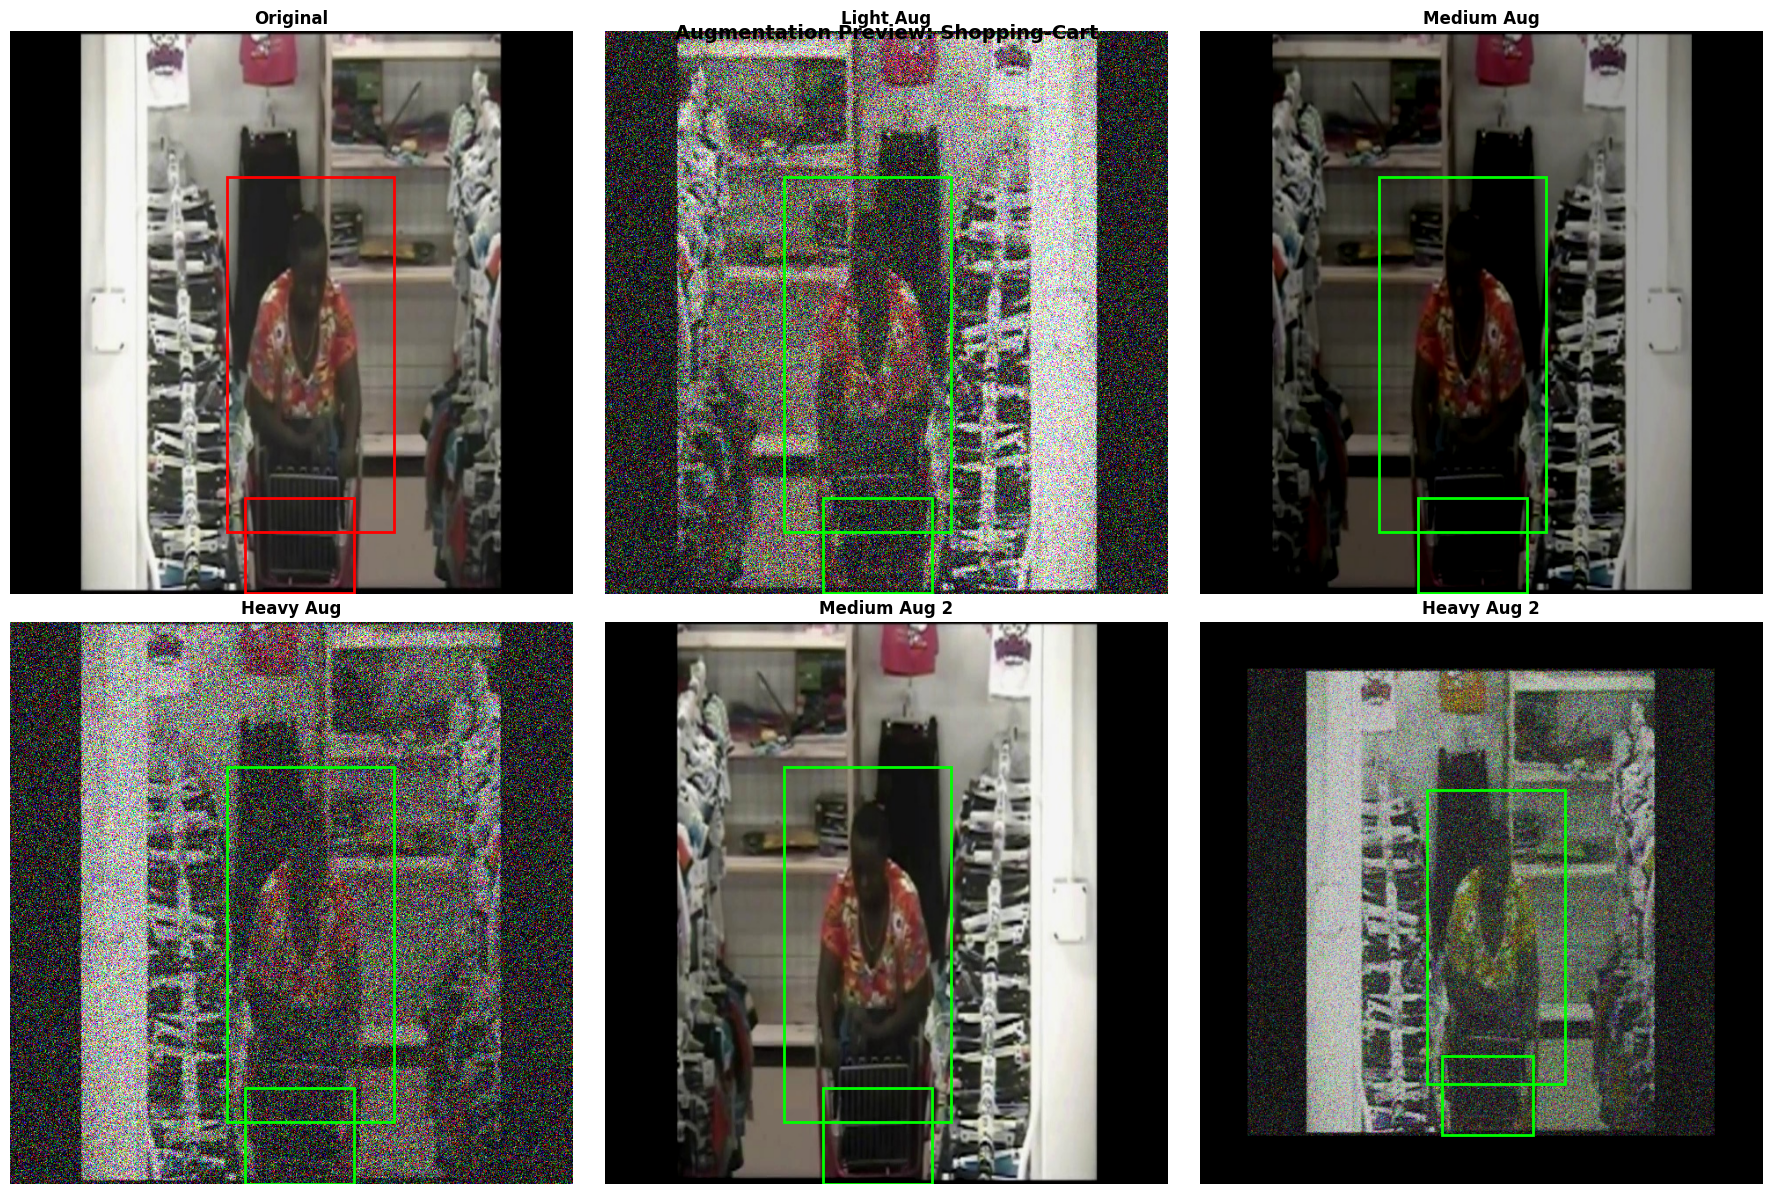


Previewing augmentations for: theft


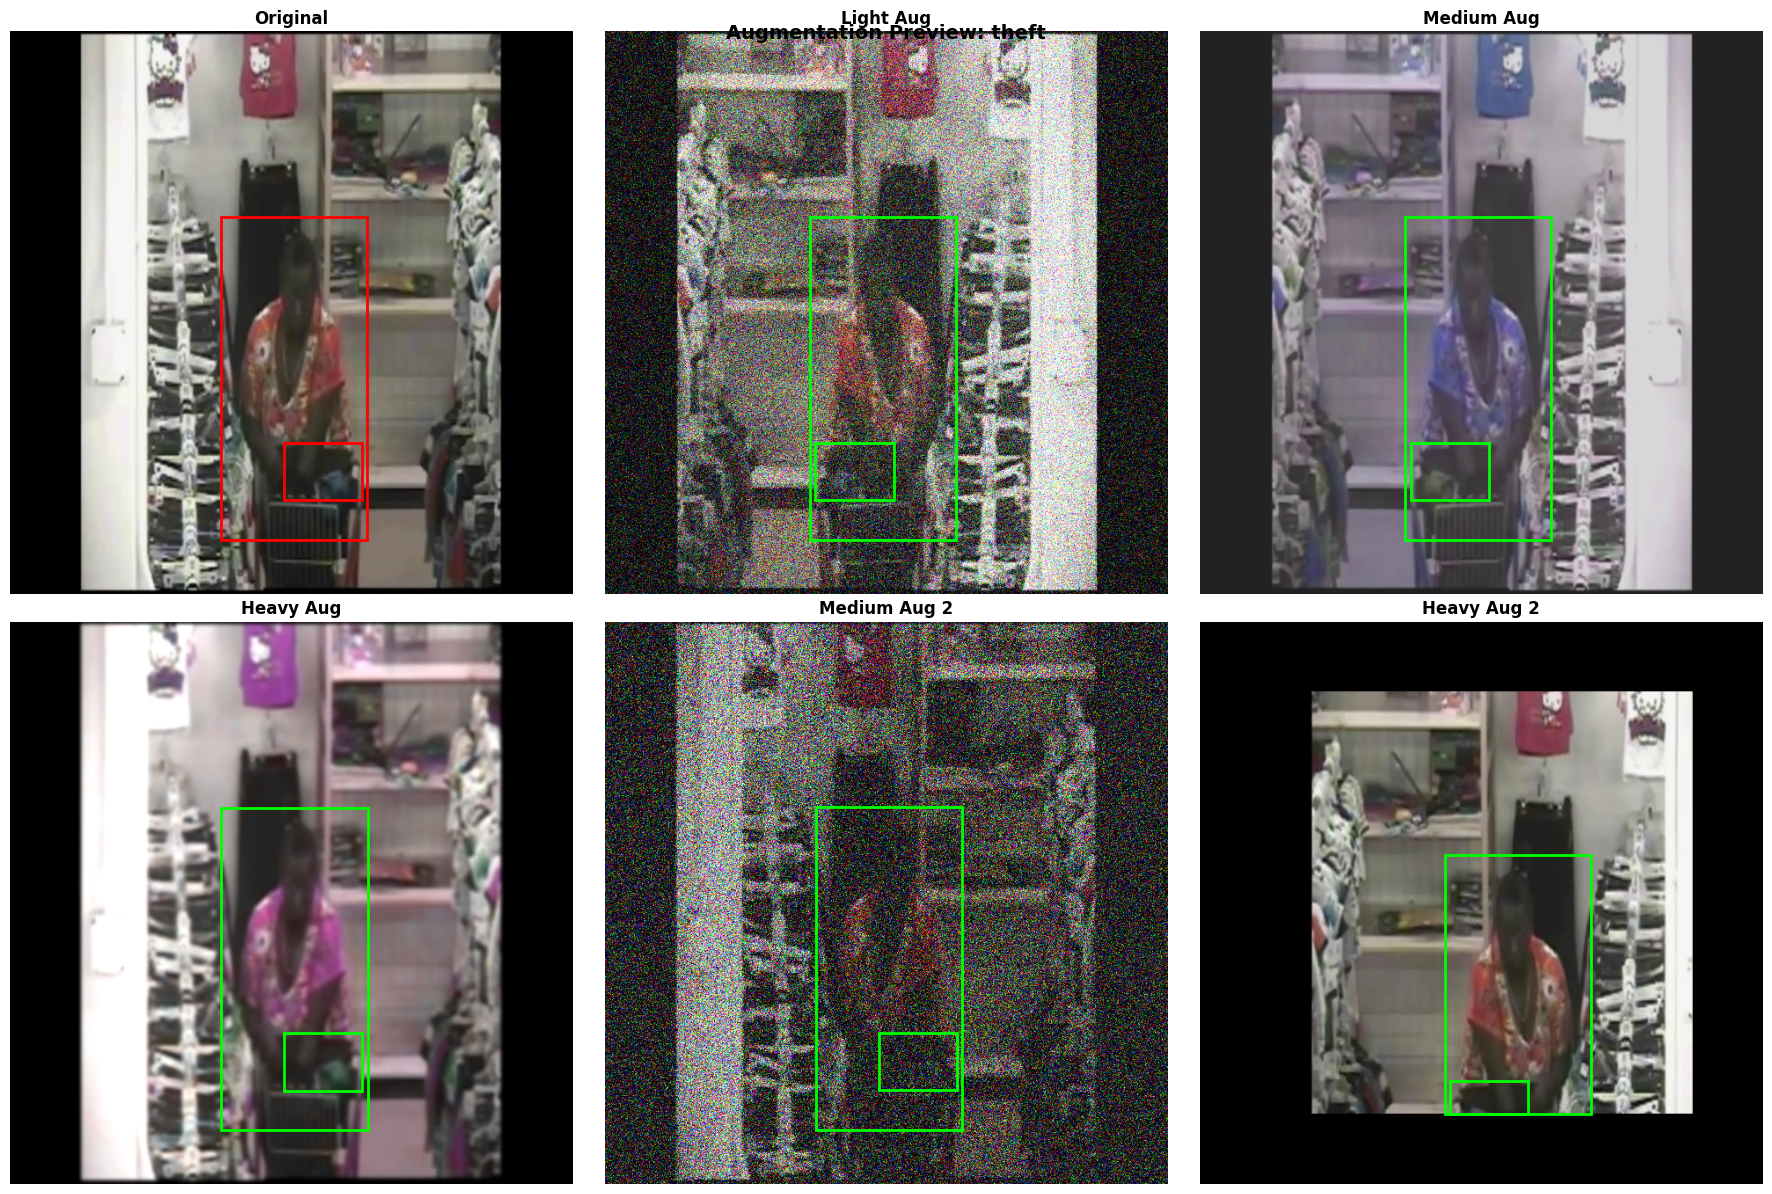

In [12]:
# Preview augmentation on sample images from minority classes
print("Generating augmentation previews...")

for class_id in MINORITY_CLASSES:
    class_name = CLASS_NAMES[class_id]
    print(f"\nPreviewing augmentations for: {class_name}")
    
    # Find an image with this class
    if class_id in images_per_class and len(images_per_class[class_id]) > 0:
        sample = random.choice(images_per_class[class_id])
        split = sample['split']
        stem = sample['image_stem']
        
        # Find image file
        images_path = SOURCE_DIR / split / "images"
        labels_path = SOURCE_DIR / split / "labels"
        
        for ext in IMAGE_EXTENSIONS:
            img_path = images_path / (stem + ext)
            if img_path.exists():
                label_path = labels_path / (stem + '.txt')
                fig = preview_augmentations(img_path, label_path)
                plt.suptitle(f'Augmentation Preview: {class_name}', fontsize=14, fontweight='bold')
                plt.savefig(VIS_DIR / f'augmentation_preview_{class_name.lower().replace("-", "_")}.png', 
                           dpi=150, bbox_inches='tight')
                plt.show()
                break

## 6. Apply Targeted Augmentation

In [13]:
def apply_targeted_augmentation(source_dir: Path, output_dir: Path, 
                                 minority_classes: set, multipliers: Dict[int, int]):
    """Apply augmentation to balance minority classes.
    
    Args:
        source_dir: Source dataset directory
        output_dir: Output directory for augmented dataset
        minority_classes: Set of class IDs to augment
        multipliers: Dict mapping class_id to augmentation multiplier
    """
    
    stats = {
        'original_copied': 0,
        'augmented_created': 0,
        'augmented_per_class': defaultdict(int),
        'failed': 0
    }
    
    # Process train split only (augmentation should not be applied to val/test)
    for split in ['train']:
        source_images = source_dir / split / "images"
        source_labels = source_dir / split / "labels"
        
        output_images = output_dir / split / "images"
        output_labels = output_dir / split / "labels"
        
        output_images.mkdir(parents=True, exist_ok=True)
        output_labels.mkdir(parents=True, exist_ok=True)
        
        if not source_images.exists():
            continue
        
        image_files = [f for f in source_images.iterdir() 
                       if f.suffix.lower() in IMAGE_EXTENSIONS]
        
        print(f"\nProcessing {split} split: {len(image_files)} images")
        
        for img_path in tqdm(image_files, desc=f"Augmenting {split}"):
            label_path = source_labels / (img_path.stem + '.txt')
            
            # Copy original
            shutil.copy2(img_path, output_images / img_path.name)
            if label_path.exists():
                shutil.copy2(label_path, output_labels / label_path.name)
            stats['original_copied'] += 1
            
            # Check if image contains minority class
            bboxes, class_labels = load_yolo_annotations(label_path)
            
            image_minority_classes = set(class_labels) & minority_classes
            
            if image_minority_classes:
                # Determine multiplier (use max if multiple minority classes)
                max_multiplier = max(multipliers.get(c, 1) for c in image_minority_classes)
                
                # Create augmented copies
                for aug_idx in range(max_multiplier):
                    # Alternate between medium and heavy augmentation
                    transform = aug_medium if aug_idx % 2 == 0 else aug_heavy
                    
                    aug_stem = f"{img_path.stem}_aug{aug_idx}"
                    aug_image_path = output_images / f"{aug_stem}{img_path.suffix}"
                    aug_label_path = output_labels / f"{aug_stem}.txt"
                    
                    success = augment_image(
                        img_path, label_path, transform,
                        aug_image_path, aug_label_path
                    )
                    
                    if success:
                        stats['augmented_created'] += 1
                        for c in image_minority_classes:
                            stats['augmented_per_class'][c] += 1
                    else:
                        stats['failed'] += 1
    
    # Copy validation and test sets without augmentation
    for split in ['valid', 'test']:
        source_images = source_dir / split / "images"
        source_labels = source_dir / split / "labels"
        
        output_images = output_dir / split / "images"
        output_labels = output_dir / split / "labels"
        
        output_images.mkdir(parents=True, exist_ok=True)
        output_labels.mkdir(parents=True, exist_ok=True)
        
        if source_images.exists():
            for f in source_images.iterdir():
                if f.suffix.lower() in IMAGE_EXTENSIONS:
                    shutil.copy2(f, output_images / f.name)
        
        if source_labels.exists():
            for f in source_labels.glob("*.txt"):
                shutil.copy2(f, output_labels / f.name)
        
        print(f"Copied {split} split without augmentation")
    
    return stats

In [14]:
# Define multipliers for each minority class
class_multipliers = {
    3: 2,  # Shopping-Cart: 2x augmentation
    5: 3   # theft: 3x augmentation (highest priority)
}

print("Starting targeted augmentation...")
print(f"Multipliers: {class_multipliers}")

# Apply augmentation
aug_stats = apply_targeted_augmentation(
    SOURCE_DIR, AUGMENTED_DIR,
    MINORITY_CLASSES, class_multipliers
)

print("\n" + "="*70)
print("AUGMENTATION RESULTS")
print("="*70)
print(f"Original images copied: {aug_stats['original_copied']:,}")
print(f"Augmented images created: {aug_stats['augmented_created']:,}")
print(f"Failed augmentations: {aug_stats['failed']:,}")

print("\nAugmented per class:")
for class_id, count in aug_stats['augmented_per_class'].items():
    print(f"  {CLASS_NAMES[class_id]}: {count:,}")

Starting targeted augmentation...
Multipliers: {3: 2, 5: 3}

Processing train split: 1314 images


Augmenting train: 100%|██████████| 1314/1314 [00:45<00:00, 28.69it/s] 


Copied valid split without augmentation
Copied test split without augmentation

AUGMENTATION RESULTS
Original images copied: 1,314
Augmented images created: 751
Failed augmentations: 0

Augmented per class:
  Shopping-Cart: 202
  theft: 615


## 7. Verify New Class Distribution

In [15]:
# Analyze new distribution
print("\nAnalyzing augmented dataset...")
new_class_counts, new_images_per_class = count_class_distribution(AUGMENTED_DIR)

print("\n" + "="*70)
print("CLASS DISTRIBUTION COMPARISON")
print("="*70)

comparison_data = []
for class_id in sorted(set(class_counts.keys()) | set(new_class_counts.keys())):
    old_count = class_counts.get(class_id, 0)
    new_count = new_class_counts.get(class_id, 0)
    increase = new_count - old_count
    pct_increase = (increase / old_count * 100) if old_count > 0 else 0
    
    comparison_data.append({
        'class_id': class_id,
        'class_name': CLASS_NAMES.get(class_id, f'Unknown-{class_id}'),
        'original': old_count,
        'augmented': new_count,
        'increase': increase,
        'pct_increase': pct_increase
    })
    
    print(f"  {CLASS_NAMES.get(class_id, f'Unknown-{class_id}'):20s} | "
          f"Original: {old_count:6,} | Augmented: {new_count:6,} | +{increase:,} ({pct_increase:.1f}%)")

comparison_df = pd.DataFrame(comparison_data)


Analyzing augmented dataset...

CLASS DISTRIBUTION COMPARISON
  Customer-Bagpack     | Original:    605 | Augmented:    605 | +0 (0.0%)
  Product              | Original:    793 | Augmented:    793 | +0 (0.0%)
  Product-Picked       | Original:    778 | Augmented:    778 | +0 (0.0%)
  Shopping-Cart        | Original:    137 | Augmented:    137 | +0 (0.0%)
  normal               | Original:  4,626 | Augmented:  4,626 | +0 (0.0%)
  theft                | Original:    396 | Augmented:    396 | +0 (0.0%)


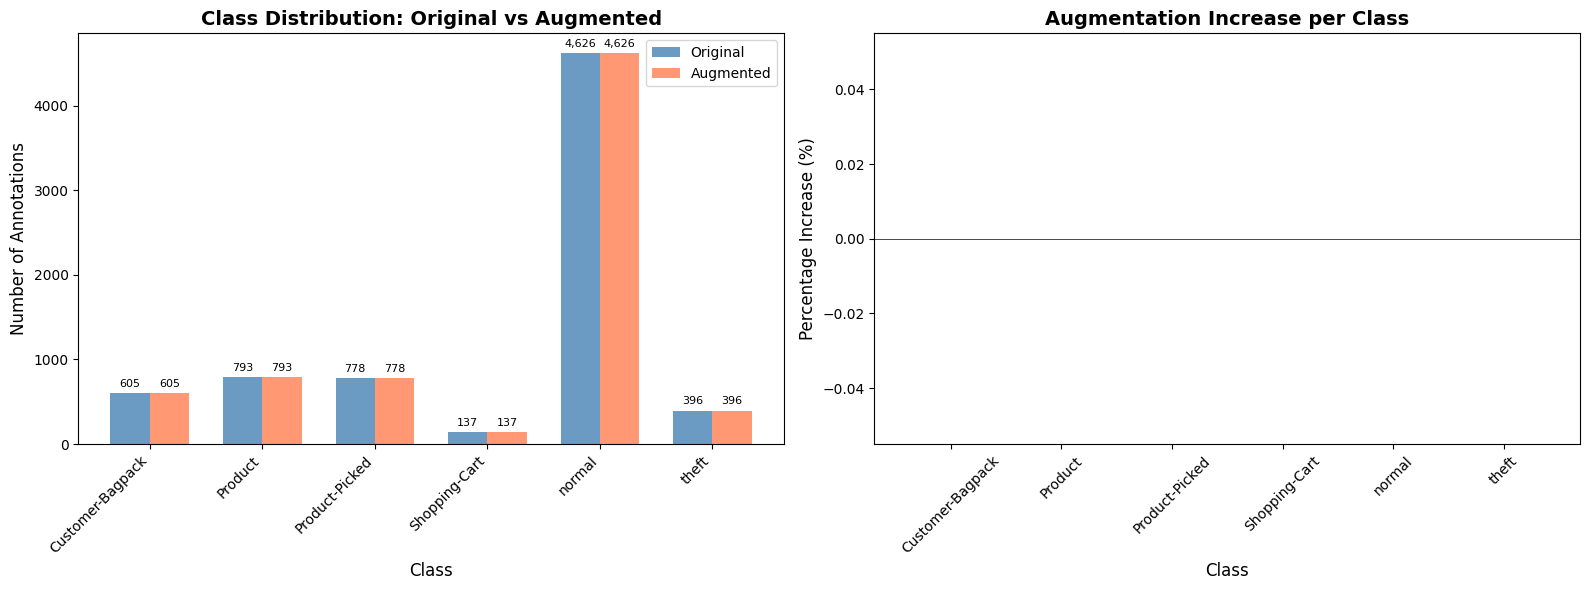

In [16]:
# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x = np.arange(len(comparison_df))
width = 0.35

# Bar comparison
bars1 = axes[0].bar(x - width/2, comparison_df['original'], width, label='Original', color='steelblue', alpha=0.8)
bars2 = axes[0].bar(x + width/2, comparison_df['augmented'], width, label='Augmented', color='coral', alpha=0.8)

axes[0].set_xlabel('Class', fontsize=12)
axes[0].set_ylabel('Number of Annotations', fontsize=12)
axes[0].set_title('Class Distribution: Original vs Augmented', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(comparison_df['class_name'], rotation=45, ha='right')
axes[0].legend()

# Add value labels
for bar in bars1:
    height = bar.get_height()
    axes[0].annotate(f'{int(height):,}',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 3),
                     textcoords="offset points",
                     ha='center', va='bottom', fontsize=8)

for bar in bars2:
    height = bar.get_height()
    axes[0].annotate(f'{int(height):,}',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 3),
                     textcoords="offset points",
                     ha='center', va='bottom', fontsize=8)

# Percentage increase
colors = ['green' if v > 0 else 'gray' for v in comparison_df['pct_increase']]
bars3 = axes[1].bar(comparison_df['class_name'], comparison_df['pct_increase'], color=colors, alpha=0.8)
axes[1].set_xlabel('Class', fontsize=12)
axes[1].set_ylabel('Percentage Increase (%)', fontsize=12)
axes[1].set_title('Augmentation Increase per Class', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)

for bar, val in zip(bars3, comparison_df['pct_increase']):
    if val > 0:
        axes[1].annotate(f'+{val:.1f}%',
                         xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                         xytext=(0, 3),
                         textcoords="offset points",
                         ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(VIS_DIR / 'augmentation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Copy data.yaml

In [17]:
# Copy and update data.yaml for augmented dataset
source_yaml = SOURCE_DIR / "data.yaml"
output_yaml = AUGMENTED_DIR / "data.yaml"

if source_yaml.exists():
    with open(source_yaml, 'r') as f:
        data_config = yaml.safe_load(f)
    
    # Update paths
    data_config['train'] = 'train/images'
    data_config['val'] = 'valid/images'
    data_config['test'] = 'test/images'
    
    with open(output_yaml, 'w') as f:
        yaml.dump(data_config, f, default_flow_style=False)
    
    print(f"data.yaml saved to: {output_yaml}")
else:
    # Create new data.yaml
    data_config = {
        'train': 'train/images',
        'val': 'valid/images',
        'test': 'test/images',
        'nc': NUM_CLASSES,
        'names': list(CLASS_NAMES.values())
    }
    
    with open(output_yaml, 'w') as f:
        yaml.dump(data_config, f, default_flow_style=False)
    
    print(f"Created new data.yaml at: {output_yaml}")

data.yaml saved to: c:\Users\shaho\OneDrive - Nile University\Desktop\AletrixGrad\dataset_augmented\data.yaml


## 9. Save Augmentation Report

In [18]:
# Save augmentation report
augmentation_report = {
    'timestamp': datetime.now().isoformat(),
    'source_dataset': str(SOURCE_DIR),
    'output_dataset': str(AUGMENTED_DIR),
    'minority_classes': [CLASS_NAMES[c] for c in MINORITY_CLASSES],
    'multipliers': {CLASS_NAMES[k]: v for k, v in class_multipliers.items()},
    'statistics': {
        'original_copied': aug_stats['original_copied'],
        'augmented_created': aug_stats['augmented_created'],
        'failed': aug_stats['failed']
    },
    'original_distribution': {CLASS_NAMES[k]: v for k, v in class_counts.items()},
    'augmented_distribution': {CLASS_NAMES[k]: v for k, v in new_class_counts.items()},
    'comparison': comparison_df.to_dict('records')
}

report_path = OUTPUT_DIR / 'augmentation_report.json'
with open(report_path, 'w') as f:
    json.dump(augmentation_report, f, indent=2)

print(f"Augmentation report saved to: {report_path}")

Augmentation report saved to: c:\Users\shaho\OneDrive - Nile University\Desktop\AletrixGrad\outputs\augmentation_report.json


In [19]:
# Final summary
print("\n" + "="*70)
print("AUGMENTATION COMPLETE")
print("="*70)

# Count files in augmented dataset
for split in ['train', 'valid', 'test']:
    images_path = AUGMENTED_DIR / split / "images"
    labels_path = AUGMENTED_DIR / split / "labels"
    
    num_images = len(list(images_path.glob("*.*"))) if images_path.exists() else 0
    num_labels = len(list(labels_path.glob("*.txt"))) if labels_path.exists() else 0
    
    print(f"\n{split.upper()}:")
    print(f"  Images: {num_images:,}")
    print(f"  Labels: {num_labels:,}")

print(f"\nAugmented dataset saved to: {AUGMENTED_DIR}")
print("\n" + "="*70)


AUGMENTATION COMPLETE

TRAIN:
  Images: 2,065
  Labels: 2,065

VALID:
  Images: 482
  Labels: 482

TEST:
  Images: 256
  Labels: 256

Augmented dataset saved to: c:\Users\shaho\OneDrive - Nile University\Desktop\AletrixGrad\dataset_augmented



---

## Next Steps

After balancing, proceed to:
1. **05_dataset_splitting.ipynb** - Verify stratified splits
2. **06_preprocessing_pipeline.ipynb** - Prepare images for training
3. **07_training_preparation.ipynb** - Configure YOLOv8s training

---